<a href="https://colab.research.google.com/github/rasikacs23172/mechine-learning-tae/blob/main/model_2_SVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.svm import SVC, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import pandas as pd
from io import StringIO

file_path = '/content/student-mat.csv'

# Read the file content manually
with open(file_path, 'r') as f:
    lines = f.readlines()

# Extract header from the first line and split it
header_line = lines[0].strip()
column_names = header_line.split(';')

# Process data lines: remove the outer double quotes that encapsulate the entire line
processed_data_lines_content = []
for line in lines[1:]:
    stripped_line = line.strip() # Remove trailing newline and any leading/trailing whitespace
    if stripped_line.startswith('"') and stripped_line.endswith('"'):
        # If the line is entirely wrapped in quotes, remove them
        processed_data_lines_content.append(stripped_line[1:-1])
    else:
        processed_data_lines_content.append(stripped_line)

# Join the processed lines to form a single string that StringIO can read.
data_string = "\n".join(processed_data_lines_content)

# Read the processed data string using pandas, now it should parse semicolons correctly.
# pandas will handle `""` (double quotes for escaped quotes) by default.
df = pd.read_csv(StringIO(data_string), sep=';', header=None)
df.columns = column_names

print("Dataset loaded successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded successfully. Displaying the first 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,"F""""",18,"U""""","GT3""""","A""""",4,4,"at_home""""","teacher""""",...,4,3,4,1,1,3,6,"5""""","6""""",6
1,GP,"F""""",17,"U""""","GT3""""","T""""",1,1,"at_home""""","other""""",...,5,3,3,1,1,3,4,"5""""","5""""",6
2,GP,"F""""",15,"U""""","LE3""""","T""""",1,1,"at_home""""","other""""",...,4,3,2,2,3,3,10,"7""""","8""""",10
3,GP,"F""""",15,"U""""","GT3""""","T""""",4,2,"health""""","services""""",...,3,2,2,1,1,5,2,"15""""","14""""",15
4,GP,"F""""",16,"U""""","GT3""""","T""""",3,3,"other""""","other""""",...,4,3,2,1,2,5,4,"6""""","10""""",10


In [4]:
print("DataFrame Info:")
df.info()

print("\nMissing values per column:")
df.isnull().sum()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                               --------------  ----- 
 0   school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3  395 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB

Missing values per column:


,0
school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3,0


In [14]:
for col in ['G1', 'G2', 'G3', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']:
    df[col] = pd.to_numeric(df[col])

categorical_cols = [
    'school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
    'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic'
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop('G3', axis=1) # Target is 'G3'
y = df_encoded['G3']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Data preprocessing and feature engineering completed.")

Shape of X_train_scaled: (316, 41)
Shape of X_test_scaled: (79, 41)
Shape of y_train: (316,)
Shape of y_test: (79,)
Data preprocessing and feature engineering completed.


In [16]:
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)

print("SVR model trained successfully.")

SVR model trained successfully.


In [17]:
y_pred = svr_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation on Test Set:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Model Evaluation on Test Set:
Mean Absolute Error (MAE): 1.8367
Mean Squared Error (MSE): 7.4312
R-squared (R2): 0.6376


In [18]:
import matplotlib.pyplot as plt

print("Matplotlib imported successfully.")

Matplotlib imported successfully.


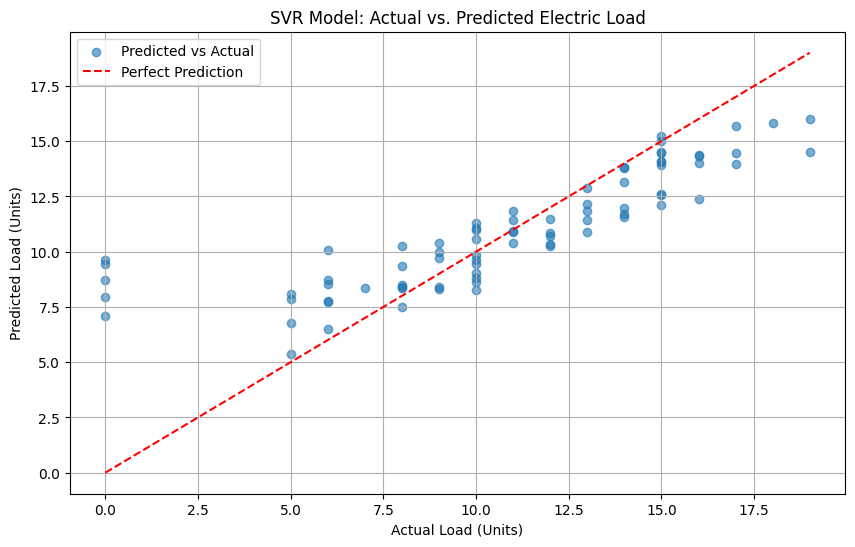

Prediction visualization completed.


In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, label='Predicted vs Actual')

# Add a line for perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Load (Units)')
plt.ylabel('Predicted Load (Units)')
plt.title('SVR Model: Actual vs. Predicted Electric Load')
plt.legend()
plt.grid(True)
plt.show()

print("Prediction visualization completed.")

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

def prepare_data(df, test_size):
    """Splits data, applies one-hot encoding, and scales features."""
    categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
                        'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
                        'nursery', 'higher', 'internet', 'romantic']
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    X = df_encoded.drop('G3', axis=1) # Target is 'G3'
    y = df_encoded['G3']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

def train_and_evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test):
    """Trains a model, makes predictions, and calculates evaluation metrics."""
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metrics = {
        'MAE': mae,
        'MSE': mse,
        'R2': r2
    }
    return metrics

print("Data preparation and model training/evaluation functions defined.")

# --- 80:20 Split ---
print("\n--- Processing 80:20 Split (test_size=0.2) ---")
X_train_scaled_0_2, X_test_scaled_0_2, y_train_0_2, y_test_0_2 = prepare_data(df, test_size=0.2)

svr_model_0_2 = SVR(kernel='rbf')
metrics_0_2 = train_and_evaluate_model(svr_model_0_2, X_train_scaled_0_2, X_test_scaled_0_2, y_train_0_2, y_test_0_2)

print("SVR Model Evaluation (80:20 Split):")
metrics_df_0_2 = pd.DataFrame(metrics_0_2.items(), columns=['Metric', 'Value'])
metrics_df_0_2.rename(columns={'Value': '80:20 Split'}, inplace=True)
display(metrics_df_0_2.round(4))

# --- 70:30 Split ---
print("\n--- Processing 70:30 Split (test_size=0.3) ---")
X_train_scaled_0_3, X_test_scaled_0_3, y_train_0_3, y_test_0_3 = prepare_data(df, test_size=0.3)

svr_model_0_3 = SVR(kernel='rbf')
metrics_0_3 = train_and_evaluate_model(svr_model_0_3, X_train_scaled_0_3, X_test_scaled_0_3, y_train_0_3, y_test_0_3)

print("SVR Model Evaluation (70:30 Split):")
metrics_df_0_3 = pd.DataFrame(metrics_0_3.items(), columns=['Metric', 'Value'])
metrics_df_0_3.rename(columns={'Value': '70:30 Split'}, inplace=True)
display(metrics_df_0_3.round(4))

Data preparation and model training/evaluation functions defined.

--- Processing 80:20 Split (test_size=0.2) ---
SVR Model Evaluation (80:20 Split):


,Metric,80:20 Split
0,MAE,1.8367
1,MSE,7.4312
2,R2,0.6376



--- Processing 70:30 Split (test_size=0.3) ---
SVR Model Evaluation (70:30 Split):


,Metric,70:30 Split
0,MAE,1.9972
1,MSE,9.2180
2,R2,0.5807


In [13]:
import pandas as pd
from io import StringIO

file_path = '/content/student-mat.csv'

# Read the file content manually
with open(file_path, 'r') as f:
    lines = f.readlines()

# Extract header from the first line and split it
header_line = lines[0].strip()
column_names = header_line.split(';')

# Process data lines: remove the outer double quotes that encapsulate the entire line
processed_data_lines_content = []
for line in lines[1:]:
    stripped_line = line.strip() # Remove trailing newline and any leading/trailing whitespace
    if stripped_line.startswith('"') and stripped_line.endswith('"'):
        # If the line is entirely wrapped in quotes, remove them
        processed_data_lines_content.append(stripped_line[1:-1])
    else:
        processed_data_lines_content.append(stripped_line)

# Join the processed lines to form a single string that StringIO can read.
data_string = "\n".join(processed_data_lines_content)

# Read the processed data string using pandas, now it should parse semicolons correctly.
# pandas will handle `""` (double quotes for escaped quotes) by default.
df = pd.read_csv(StringIO(data_string), sep=';', header=None)
df.columns = column_names

# Clean up extra double quotes within string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.replace('""', '', regex=False)
    df[col] = df[col].str.strip()

print("Dataset loaded and cleaned successfully. Displaying the first 5 rows:")
df.head()

Dataset loaded and cleaned successfully. Displaying the first 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
